Dylan Ross

Compute associations between significantly altered lipids and proteins

## Setup

### Imports

In [1]:
import os
import pickle

import networkx as nx
import numpy as np
import polars as pl
from scipy import stats
from matplotlib import pyplot as plt, rcParams

# set max font size 
rcParams["font.size"] = 7

### Constants

In [2]:
# Jupyter server should be running from src/python

CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache"
)

# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_figures",
    "assoc"
)

# directory for differentially expressed features
DIFFEX_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache",
    "diffex"
)

### Utility

In [3]:
def load_data(
    subset_id: str,
    block: str
) :
    """ 
    loads a specified -omics block for a selected data subset
    """
    # load subset sample columns
    with open(os.path.join(CACHE_DIR, f"{subset_id}_cols.pkl"), "rb") as pf:
        wt_cols, mut_cols = pickle.load(pf)

    # load subset omics data
    omics_subset = pl.read_ipc(os.path.join(CACHE_DIR, f"{subset_id}.arrow"))

    # select out the block of interest, drop null columns, return
    subset = (
        omics_subset
        .filter(pl.col("Block") == block)
        .drop("Block")
    )
    # drop any all-null columns
    return wt_cols, mut_cols, subset[[
        c.name 
        for c in subset 
        if not (c.null_count() == subset.height)
    ]]

In [4]:
def load_diffex_data(
    subset_id: str,
    block: str, 
    up_or_down: str
) :
    # load the significant feature data
    subset = (
        pl.read_csv(
            os.path.join(
                DIFFEX_DIR,
                f"{subset_id}_{block}_{up_or_down}.csv"
            )
        )
        # keep only the z-scores
        .drop(
            "delta_z",
            "ttest_p"
        )
    )
    # drop any all-null columns
    return subset[[
        c.name 
        for c in subset 
        if not (c.null_count() == subset.height)
    ]]

In [5]:
def correlate_with_lipids(
    subset_id,
    block,
    up_or_down_lipids
) : 
    print("=" * 60)
    print(f"{subset_id=} {block=} {up_or_down_lipids=}")
    # load lipidomics and protein data, select common samples
    wt_cols, mut_cols, p_df = load_data(subset_id, block)
    l_df = load_diffex_data(subset_id, "Lipidomics", up_or_down_lipids)
    common_cols = set(p_df.columns) & set(l_df.columns)
    print(f"{len(common_cols)} columns in common")
    print(f"\t{len(set(wt_cols) & common_cols)} WT samples")
    print(f"\t{len(set(mut_cols) & common_cols)} mutant samples")
    # check that there are sufficient numbers of WT and mutant samples
    # among the common columns
    p_mat = p_df.select(common_cols).drop("Feature").to_numpy()
    l_mat = l_df.select(common_cols).drop("Feature").to_numpy()
    # compute correlations with p-values
    results = []
    for p, p_data in zip(p_df["Feature"], p_mat):
        # fill NaNs with row minimum
        p_data[np.isnan(p_data)] = np.nanmin(p_data)
        for l, l_data in zip(l_df["Feature"], l_mat):
            # fill NaNs with row minimum
            l_data[np.isnan(l_data)] = np.nanmin(l_data)
            r, pv = stats.spearmanr(p_data, l_data)
            results.append({
                "protein": p,
                "lipid": l,
                "correlation": r,
                "p_value": pv,
                "p_data": p_data,
                "l_data": l_data
            })
    # create a dataframe from the correlation results
    corr = (
        pl.DataFrame(results)
        .sort(
            pl.col("correlation").abs(),
            descending=True
        )
    )
    corr = (
        corr
        # correct p-values for multiple comparisons
        # Benjamini-Hochberg
        .with_columns(
            pl.Series(
                "p_adj", 
                stats.false_discovery_control(corr["p_value"].to_numpy())
            )
        )
        # only keep correlations that are significant
        # and have a moderate effect size
        .filter(
            (pl.col("p_adj") <= 0.05)
            & (pl.col("correlation") >= 0.5)
        )
    )
    print(f"{len(corr)} correlations meet significant and correlation threshold")
    if len(corr) > 0:
        print(f"\t{len(corr["protein"].unique())} proteins")
        print(f"\t{len(corr["lipid"].unique())} lipids")
        return corr
    return None

In [6]:
def write_associated_protein_list(
    corrs,
    subset,
    up_or_down_lipids
):
    corr_tx = corrs[(subset, "Transcriptomics", up_or_down_lipids)]
    corr_px = corrs[(subset, "Proteomics", up_or_down_lipids)]
    df = None
    if corr_tx is not None and corr_px is not None:
        df = pl.concat([
            corr_tx,
            corr_px
        ])
    elif corr_tx is not None:
        df = corr_tx
    elif corr_px is not None:
        df = corr_px
    if df is not None:
        (
            df    
            .group_by("protein")
            .agg(
                "lipid",
                "correlation",
                "p_adj",
                "p_data",
                "l_data"
            )
            .head(200)
            .select("protein")
            .write_csv(
                os.path.join(
                    CACHE_DIR,
                    "diffex",
                    f"{subset}_Lipid-Protein-Associations_{up_or_down_lipids}.txt"
                ),
                include_header=False
            )
        )

## Analysis

In [7]:
corrs = {
    (subset_id, block, up_or_down_lipids): correlate_with_lipids(
        subset_id,
        block,
        up_or_down_lipids
    )
    for subset_id in [
        "B_NPM1-WT", 
        "W_NPM1-WT", 
        "B_FLT3-ITD-WT", 
        "W_FLT3-ITD-WT", 
        "B_FLT3-ITDxNPM1-WT", 
        "W_FLT3-ITDxNPM1-WT"
    ]
    for block in [
        "Transcriptomics", 
        "Proteomics", 
    ]
    for up_or_down_lipids in [
        "up",
        "down"
    ]
}

subset_id='B_NPM1-WT' block='Transcriptomics' up_or_down_lipids='up'
54 columns in common
	47 WT samples
	6 mutant samples
644 correlations meet significant and correlation threshold
	436 proteins
	22 lipids
subset_id='B_NPM1-WT' block='Transcriptomics' up_or_down_lipids='down'
54 columns in common
	47 WT samples
	6 mutant samples
327 correlations meet significant and correlation threshold
	306 proteins
	13 lipids
subset_id='B_NPM1-WT' block='Proteomics' up_or_down_lipids='up'
71 columns in common
	62 WT samples
	8 mutant samples
53 correlations meet significant and correlation threshold
	46 proteins
	7 lipids
subset_id='B_NPM1-WT' block='Proteomics' up_or_down_lipids='down'
71 columns in common
	62 WT samples
	8 mutant samples
445 correlations meet significant and correlation threshold
	439 proteins
	7 lipids
subset_id='W_NPM1-WT' block='Transcriptomics' up_or_down_lipids='up'
45 columns in common
	31 WT samples
	13 mutant samples
0 correlations meet significant and correlation thresh

In [8]:
for subset_id in [
    "B_NPM1-WT", 
    "W_NPM1-WT", 
    "B_FLT3-ITD-WT", 
    "W_FLT3-ITD-WT", 
    "B_FLT3-ITDxNPM1-WT", 
    "W_FLT3-ITDxNPM1-WT"
]:
    for up_or_down_lipids in [
        "up",
        "down"
    ]:
        write_associated_protein_list(
            corrs,
            subset_id,
            up_or_down_lipids
        )

TypeError: string indices must be integers, not 'str'

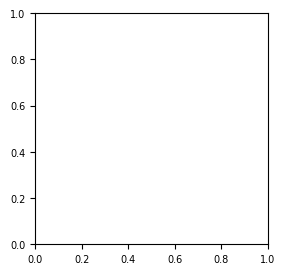

In [63]:
fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(
    d["l_data"][0],
    d["p_data"][0],
    "ko",
    fillstyle="none",
    mew=1,
    ms=4
)

for d in ["top", "right"]:
    ax.spines[d].set_visible(False)

ax.set_xlabel("Lipidomics")
ax.set_ylabel("Proteomics")

plt.show()
plt.close()